# EDA

## Univariate EDA 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [7]:
df = pd.read_csv('/Users/javohireshonov/Desktop/Study/Projects/Uzbekistan car postings /data/Prepared/car_data_clean.csv')

In [8]:
df.head()

,url,region,district,price_raw,currency,description,image_url,model_raw,body_type,sale_type,...,model_clean,car_name,brand,price_usd,mileage_raw,mileage_log,mileage_group,engine_volume_raw,engine_volume_l,sale_type_raw
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,Jizzakh,Gallaaral,15000000.0,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2103,Sedan,NaN,...,2103,Lada 2103,Lada,1250.0,NaN,NaN,NaN,12,1.20,NaN
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,Namangan,Namangan,15000000.0,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2105,Sedan,Simple Sale,...,2105,Lada 2105,Lada,1250.0,72122.0,11.186128,medium,1,1.00,Simple Sale
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,Khorezm,Karaul,15000000.0,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 2101,Convertible,NaN,...,2101,Lada 2101,Lada,1250.0,0.0,NaN,NaN,2103,2.10,NaN
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,Jizzakh,Mardzhanbulak,15000000.0,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 31029,Station Wagon,NaN,...,31029,GAZ 31029,GAZ,1250.0,560.0,NaN,NaN,105,1.05,NaN
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,Karakalpakstan,Kungrad,15000000.0,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,: 626,Hatchback,Simple Sale,...,626,626,Other,1250.0,NaN,NaN,NaN,16,1.60,Simple Sale


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46106 entries, 0 to 46105
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 46106 non-null  object 
 1   region              46105 non-null  object 
 2   district            46105 non-null  object 
 3   price_raw           46101 non-null  float64
 4   currency            46106 non-null  object 
 5   description         46106 non-null  object 
 6   image_url           44547 non-null  object 
 7   model_raw           46047 non-null  object 
 8   body_type           46106 non-null  object 
 9   sale_type           18321 non-null  object 
 10  year                46106 non-null  int64  
 11  mileage             35346 non-null  float64
 12  transmission        46106 non-null  object 
 13  color               46106 non-null  object 
 14  engine_volume       46106 non-null  int64  
 15  fuel_type           46106 non-null  object 
 16  cond

### Price (USD)

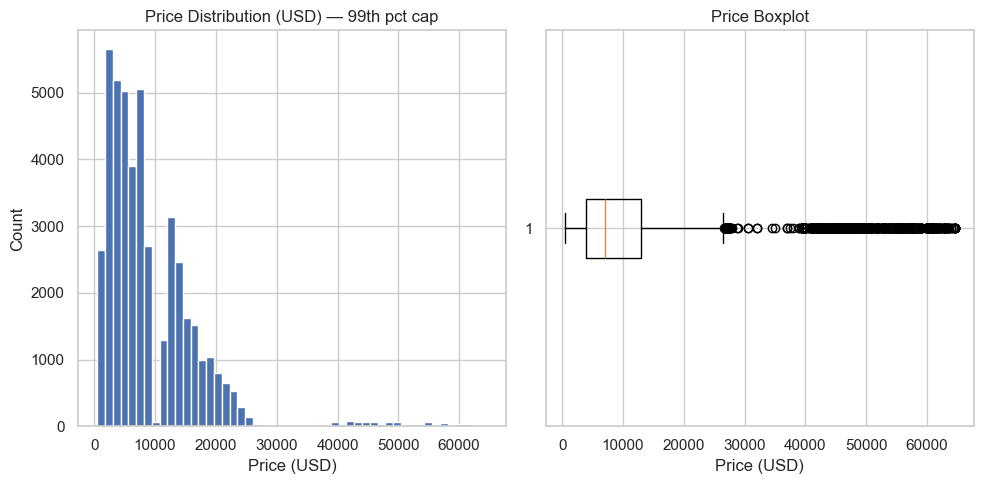

count     46101.0
mean      10047.0
std       11533.9
min         500.0
25%        3916.7
50%        7000.0
75%       13200.0
max      167414.4
Name: price_usd, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2)

price = df['price_usd'].dropna()
price_capped = price[price <= price.quantile(0.99)]

axes[0].hist(price_capped, bins=50, edgecolor='white')
axes[0].set_title('Price Distribution (USD) — 99th pct cap')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].boxplot(price_capped, vert=False)
axes[1].set_title('Price Boxplot')
axes[1].set_xlabel('Price (USD)')

plt.tight_layout()
plt.show()

print(price.describe().round(1))

### Year

In [ ]:
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(14, 5), edgecolor='white')
plt.title('Listings by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Mileage

In [ ]:
fig, axes = plt.subplots(1, 2)

mileage = df['mileage'].dropna()

axes[0].hist(mileage, bins=50, edgecolor='white')
axes[0].set_title('Mileage Distribution')
axes[0].set_xlabel('Mileage (km)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(mileage), bins=50, edgecolor='white', color='steelblue')
axes[1].set_title('Mileage Distribution (log scale)')
axes[1].set_xlabel('log(Mileage + 1)')

plt.tight_layout()
plt.show()

print(mileage.describe().round(1))

### Engine Volume

In [ ]:
df['engine_volume_l'].dropna().value_counts().sort_index().plot(kind='bar', edgecolor='white', figsize=(12, 5))
plt.title('Engine Volume Distribution (L)')
plt.xlabel('Engine Volume (L)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Categorical Counts

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['brand', 'body_type', 'transmission', 'fuel_type']):
    counts = df[col].value_counts().head(10)
    ax.barh(counts.index[::-1], counts.values[::-1])
    ax.set_title(f'Top {col}')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df['region'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.title('Listings by Region')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Bivariate EDA

### Price vs Year

In [ ]:
data = df[df['price_usd'] <= df['price_usd'].quantile(0.99)]

median_by_year = data.groupby('year')['price_usd'].median().reset_index()

plt.scatter(data['year'], data['price_usd'], alpha=0.1, s=5, label='Listings')
plt.plot(median_by_year['year'], median_by_year['price_usd'], color='red', linewidth=2, label='Median price')
plt.title('Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### Price vs Mileage

In [ ]:
data = df[
    (df['price_usd'] <= df['price_usd'].quantile(0.99)) &
    (df['mileage'].notna())
]

plt.scatter(data['mileage'], data['price_usd'], alpha=0.1, s=5)
plt.title('Price vs Mileage')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

### Price by Brand (Top 10)

In [ ]:
top_brands = df['brand'].value_counts().head(10).index
data = df[df['brand'].isin(top_brands) & (df['price_usd'] <= df['price_usd'].quantile(0.99))]

order = data.groupby('brand')['price_usd'].median().sort_values().index

sns.boxplot(data=data, x='price_usd', y='brand', order=order, flierprops=dict(markersize=2, alpha=0.3))
plt.title('Price Distribution by Brand (Top 10)')
plt.xlabel('Price (USD)')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

### Price by Body Type

In [ ]:
data = df[df['price_usd'] <= df['price_usd'].quantile(0.99)]
order = data.groupby('body_type')['price_usd'].median().sort_values().index

sns.boxplot(data=data, x='price_usd', y='body_type', order=order, flierprops=dict(markersize=2, alpha=0.3))
plt.title('Price Distribution by Body Type')
plt.xlabel('Price (USD)')
plt.ylabel('Body Type')
plt.tight_layout()
plt.show()

## Correlation

In [ ]:
num_cols = ['price_usd', 'year', 'mileage', 'engine_volume_l', 'owners_count']
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()